# Data

In [5]:
import pandas as pd

pathTrain=r"C:\Users\USER098\Documents\GitHub\Lessons_About_Data\Data\DailyDelhiClimateTrain.csv"
pathTest=r"C:\Users\USER098\Documents\GitHub\Lessons_About_Data\Data\DailyDelhiClimateTest.csv"

df = pd.read_csv(pathTrain,encoding="utf-8")
dfTest = pd.read_csv(pathTest,encoding="utf-8")

print(df.head())
print(dfTest.head())

         date   meantemp   humidity  wind_speed  meanpressure
0  2013-01-01  10.000000  84.500000    0.000000   1015.666667
1  2013-01-02   7.400000  92.000000    2.980000   1017.800000
2  2013-01-03   7.166667  87.000000    4.633333   1018.666667
3  2013-01-04   8.666667  71.333333    1.233333   1017.166667
4  2013-01-05   6.000000  86.833333    3.700000   1016.500000
         date   meantemp   humidity  wind_speed  meanpressure
0  2017-01-01  15.913043  85.869565    2.743478     59.000000
1  2017-01-02  18.500000  77.222222    2.894444   1018.277778
2  2017-01-03  17.111111  81.888889    4.016667   1018.333333
3  2017-01-04  18.700000  70.050000    4.545000   1015.700000
4  2017-01-05  18.388889  74.944444    3.300000   1014.333333


# Extract

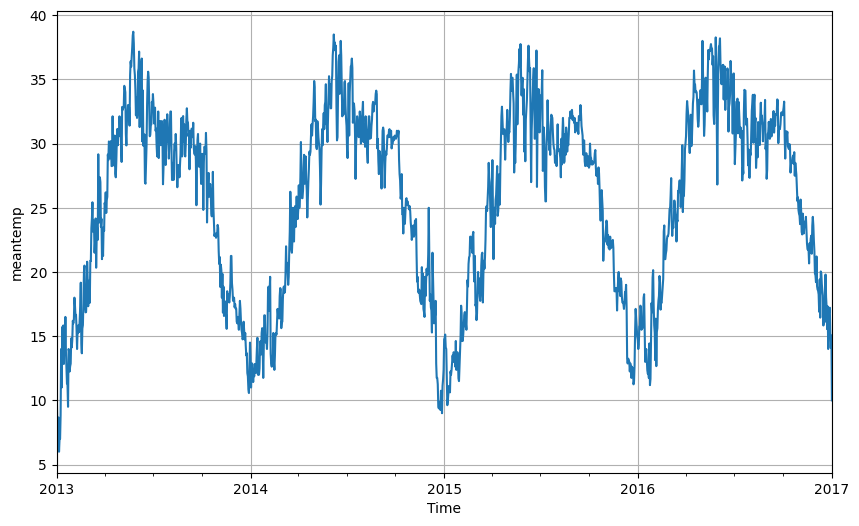

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Wczytywanie danych
path=r"C:\Users\USER098\Documents\GitHub\Lessons_About_Data\Data\DailyDelhiClimateTrain.csv"
data = pd.read_csv(path, encoding="utf-8", index_col='date', parse_dates=True)

# Wizualizacja danych
plt.figure(figsize=(10, 6))
data['meantemp'].plot(xlabel="Time", ylabel="meantemp")
plt.grid()
plt.show()

# Calculate moving averages for 7-day and 30-day windows.

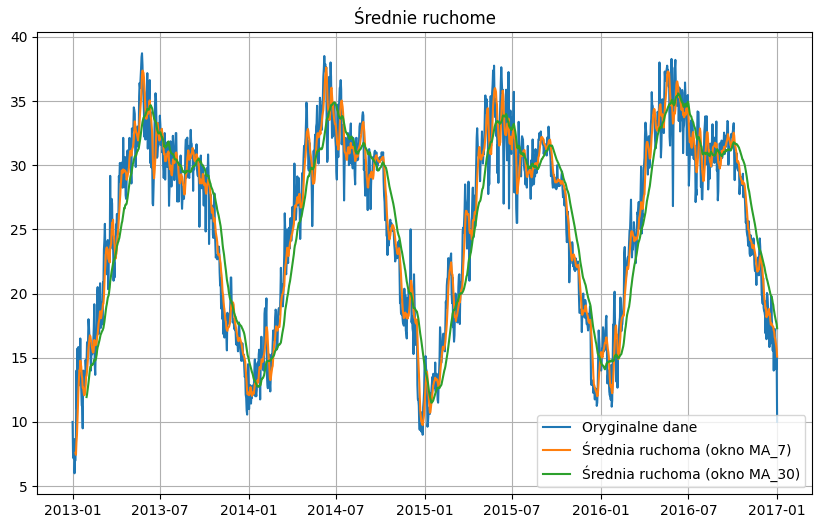

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

path=r"C:\Users\USER098\Documents\GitHub\Lessons_About_Data\Data\DailyDelhiClimateTrain.csv"
data = pd.read_csv(path, encoding="utf-8", index_col='date', parse_dates=True)

# Obliczanie średnich ruchomych
data['MA_7'] = data['meantemp'].rolling(window=7).mean()
data['MA_30'] = data['meantemp'].rolling(window=30).mean()

# Wizualizacja
plt.figure(figsize=(10, 6))
plt.plot(data['meantemp'], label="Oryginalne dane")
plt.plot(data['MA_7'], label="Średnia ruchoma (okno MA_7)")
plt.plot(data['MA_30'], label="Średnia ruchoma (okno MA_30)")
plt.title("Średnie ruchome")
plt.legend()
plt.grid()
plt.show()

# Analize of ACF and PACF.

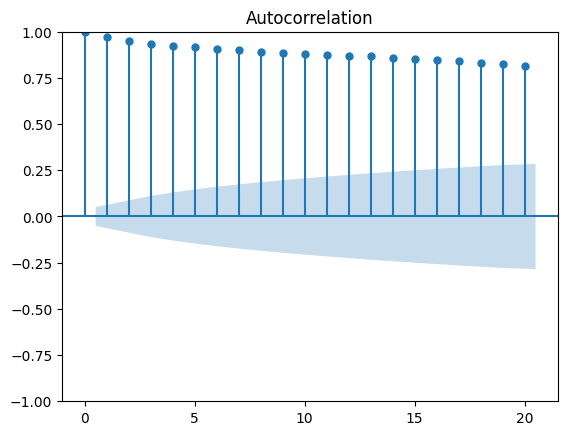

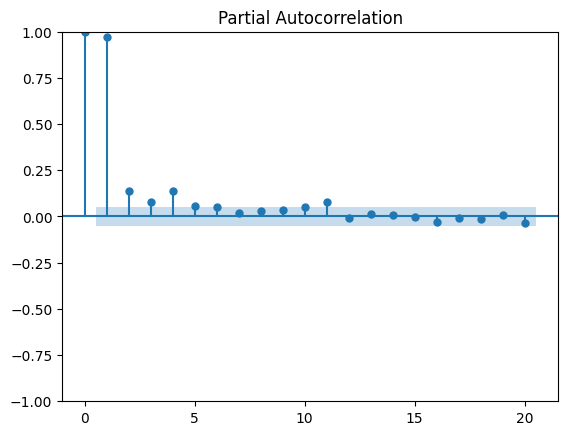

In [19]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ACF i PACF
plot_acf(data['meantemp'], lags=20, title="Autocorrelation")
plot_pacf(data['meantemp'], lags=20, title="Partial Autocorrelation", method='ywm')
plt.show()

# Decompose the data into trend, seasonality, and residual components.

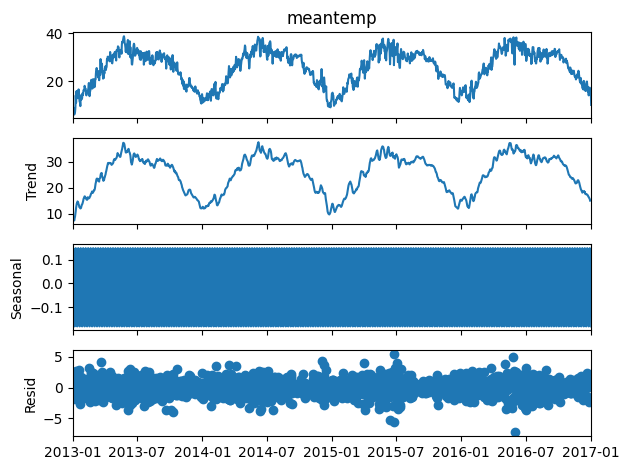

In [21]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Dekompozycja addytywna
result = seasonal_decompose(data['meantemp'], model='additive')
result.plot()
plt.show()